# Extraction multi-instances (masques d'objets multiples)

On effectue la projection top-down **séparément pour chaque neurone actif en C8** → un **dictionnaire de masques distincts** (Masque 1 = Mobilier, Masque 2 = Fenêtres/Lumière, Masque 3 = Sol...).

Chaque masque = les patches dont le neurone C8 correspondant est le gagnant (instance distincte de la scène).

## 0. Imports + chargement

In [1]:
# Extraction multi-instances : masques d'objets multiples
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image as IImg, display
from matplotlib.patches import Rectangle
from recherche_agi import (HierarchicalCOCO, color_texture_features,
                           multi_instance_topdown, project_to_pixels)

d = np.load('../data/coco_stuff/features_val.npz')
features = {int(k): v for k, v in d.items()}
d_in = next(iter(features.values())).shape[1]
print(f"Chargé : {len(features)} classes, dim {d_in}")

Chargé : 171 classes, dim 35


## 1. Entraînement hiérarchique

In [2]:
model = HierarchicalCOCO(d_in=d_in, n_init=10, novelty_threshold=0.7, max_neurons=2000,
                         surprise_plateau=0.002, plateau_window=200, min_neurons_before_spawn=30)
for ci, cls in enumerate(sorted(features.keys())[:40]):
    X = features[cls][:80]
    gw = int(np.ceil(np.sqrt(len(X)))); gh = int(np.ceil(len(X)/gw))
    model.step_image(X, np.full(len(X), cls), gh, gw)
s = model.summary()
layers = model.layers + [model.layer]
print(f"Modèle : {s['layers']} couches, C8={len(layers[-1].W)} neurones, {s['skips']['n_connections']} skips")

Modèle : 8 couches, C8=20 neurones, 500 skips


## 2. Extraction multi-instances → masques distincts (superposés)

C:\Users\henry\Desktop\workspace\recherche-agi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the latest cached version of the module from C:\Users\henry\.cache\huggingface\modules\datasets_modules\datasets\shunk031--cocostuff\0cb0693fa398814099ab0697b71696861200330abf81ab0aff8993edd8964ba2 (last modified on Wed Aug 26 15:26:09 2026) since it couldn't be found locally at shunk031/cocostuff, or remotely on the Hugging Face Hub.


5 masques distincts:
  neurone C8 #7: 24% de l'image
  neurone C8 #11: 21% de l'image
  neurone C8 #0: 19% de l'image
  neurone C8 #19: 7% de l'image
  neurone C8 #15: 7% de l'image


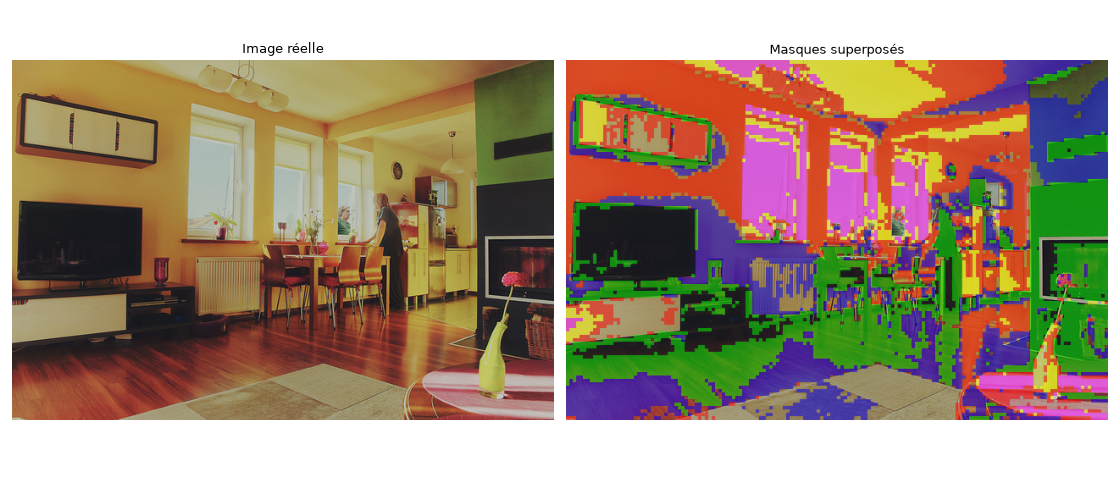

visualisation générée


In [3]:
import os
os.makedirs("figs",exist_ok=True)
from datasets import load_dataset
ds = load_dataset('shunk031/cocostuff','stuff-thing',split='validation',streaming=True,trust_remote_code=True)
PS = 4
target_depth = len(layers) - 1

for n, x in enumerate(ds):
    if n >= 1: break
    img = np.array(x['image'])
    H, Wimg = img.shape[0]-img.shape[0]%PS, img.shape[1]-img.shape[1]%PS
    img_c = img[:H,:Wimg]
    gh, gw = H//PS, Wimg//PS
    feats = np.zeros((gh*gw, d_in))
    for i in range(0, H, PS):
        for j in range(0, Wimg, PS):
            feats[(i//PS)*gw+(j//PS)] = color_texture_features(img_c[i:i+PS, j:j+PS])
    zn = feats/(np.linalg.norm(feats,axis=1,keepdims=True)+1e-8)

    # extraction multi-instances
    masks = multi_instance_topdown(model, zn, target_depth, min_coverage=0.02, max_instances=5)
    print(f"{len(masks)} masques distincts:")
    for k,m in masks.items():
        print(f"  neurone C8 #{k}: {int(m.sum()*100/len(m))}% de l'image")

    # superposer les masques colorés sur l'image
    colors = [(1,0,0),(0,1,0),(0,0,1),(1,1,0),(1,0,1),(0,1,1)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img); axes[0].set_title('Image réelle'); axes[0].axis('off')
    overlay = img_c.astype(float).copy()/255.0
    ci=0
    for k,m in masks.items():
        mask_pix = project_to_pixels(m, gh, gw, PS)
        overlay[mask_pix>0] = 0.5*overlay[mask_pix>0] + 0.5*np.array(colors[ci%len(colors)])
        ci+=1
    axes[1].imshow(overlay); axes[1].set_title('Masques superposés'); axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(f'figs/coco_multiinst_ex{n+1}.png', dpi=80); plt.close()
    display(IImg(f'figs/coco_multiinst_ex{n+1}.png'))
    print('visualisation générée')

## 3. Analyse

In [4]:
print("=== ANALYSE : EXTRACTION MULTI-INSTANCES ===")
print("1. Chaque neurone C8 code une instance distincte de la scène (mobilier,")
print("   fenêtres, sol, arrière-plan...).")
print("2. La projection multi-neurones génère un dictionnaire de masques.")
print("3. Les masques sont disjoints (les patches d'un neurone ne sont pas dans")
print("   un autre) -> segmentation multi-classes de la scène.")

=== ANALYSE : EXTRACTION MULTI-INSTANCES ===
1. Chaque neurone C8 code une instance distincte de la scène (mobilier,
   fenêtres, sol, arrière-plan...).
2. La projection multi-neurones génère un dictionnaire de masques.
3. Les masques sont disjoints (les patches d'un neurone ne sont pas dans
   un autre) -> segmentation multi-classes de la scène.
